# Gerchberg-Saxton with Chromatix

<a target="_blank" href="NOTE">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
# If in Colab, install Chromatix. Don't forget to select a GPU!
!pip install --upgrade pip
!pip install git+https://github.com/chromatix-team/chromatix.git

First, import necessary pakages:

In [2]:
import chromatix.functional as cx
import chromatix.utils.fft as cfft
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import napari
from jax import Array
from jax.scipy.ndimage import map_coordinates
import napari
from jax import random
import flax.linen as nn
from flax.training.train_state import TrainState
from optax import adam
import optax
import matplotlib.pyplot as plt
from chromatix import Field
from chromatix.utils import flat_phase
from typing import Any, Tuple
from chex import Array
from skimage import data
import numpy as np
from typing import Callable, Tuple, Any
from jax import random
key = random.PRNGKey(4)

## Load and define the target image
We can either load a random image or a geenrated one. Here for simplicity we will use a random natural image.

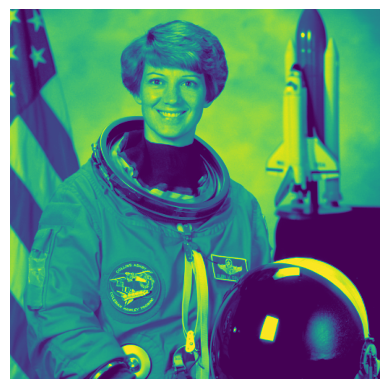

In [3]:
target = np.mean(getattr(data, 'astronaut')(), axis=-1)

# Display the image
plt.imshow(target)
plt.axis('off')  # Hide axis
plt.show()


## Forward and Inverse propagation model definitions
If the the optical system is a simple ff lens or simply propagating in free space, you can simply use the associated functional or elements modules from chromatix. However in complex optical systems, it's better to separately define your forward/backward module in a separate flax module. Then use that within your final module. Here the optical setup consists of only one lens.

In [4]:
# Optical system parameters
key = jax.random.PRNGKey(42)
# length of the field in pixels
size = target.shape[1:]
# pixel spacing
dx = 0.065
# wavelength in microns
wavelength = 0.523
# power is 1 per pixel
power = np.prod(size) * dx * dx
# Forward model is just a ff lens with a focal length of 0.1
def forward(field: Field):
    field = cx.ff_lens(field,
                       f=0.1,
                       n=1,
                       inverse=False)
    return field
# Inverse propagation is achieved by setting inverse=True
def inverse(field: Field):
    field = cx.ff_lens(field,
                       f=0.1,
                       n=1,
                       inverse=True)
    return field

The GS class is self-contained and takes the target image as input and 

In [5]:
class GerchbergSaxton(nn.Module):
    shape: Tuple[int, int]
    N: int
    forward: Callable[[Any], Any]
    inverse: Callable[[Any], Any]
    key: Any

    def setup(self):
        # Initialize any necessary variables here
        pass

    @nn.compact
    def __call__(self, target: jnp.ndarray) -> Tuple[jnp.ndarray, jnp.ndarray]:
        key = self.make_rng('key')
        # Initialize the field with random phase
        initial_phase = random.uniform(key, self.shape, dtype=jnp.float32) * 2 * jnp.pi
        field = cx.generic_field(
            amplitude=target[None, :, :, None, None],
            phase=initial_phase[None, :, :, None, None],
            dx=dx,  # Assuming dx is defined elsewhere
            spectrum=wavelength,  # Assuming wavelength is defined elsewhere
            spectral_density=1.0,
            power=power  # Assuming power is defined elsewhere
        )
        
        # for _ in range(self.N):
        field = self.inverse(field)
        # Update the field by replacing amplitude with ones and keeping the phase
        field = field.replace(
            u=jnp.ones(self.shape, dtype=jnp.complex64) * jnp.exp(1j * field.phase)
        )
        field = self.forward(field)
        
        recon = field.amplitude
        slm = self.inverse(field).phase
        return recon, slm


The final forward model is the combination of the rotation and propagation through the material. We define a function, `get_sinogram`, that given the sample and a rotation angle will apply the propagation:

In [6]:
gs = GerchbergSaxton(shape=target.shape, N=5, forward=forward, inverse=inverse, key=key)

In [7]:
params = gs.init(key, target)['params']  # This creates initial model parameters

: 